In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from VAE_EoS import Sampling
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from toolbox import pickle_load
from pathlib import Path
import joblib
from read_data import read_data

In [2]:
# For Skyrme plots:
_,_,_, X_test, _,_,_, y_test_obs, _,_,_ =read_data('./data_skyrme/')

latent_dim_variational=1
eta=0.01
kappa=5

dir_name="data_model_picked/skyrme"
outdir = dir_name+'/'+ f'latent{latent_dim_variational}_eta{eta:.2g}_kappa{kappa:.2g}' 


# #For RMF plots:
# #_,_, X_test, _,_,_, y_test_obs,_,_,_,_=read_data('./data_rmf/')
# _,_,_, X_test, _,_,_, y_test_obs, _,_,_ =read_data('./data_rmf/')

# latent_dim_variational=2
# eta=0.01
# kappa=5

# # rmf_i=3
# # dir_name="data_model_picked/rmf/data_log%d_rmf/sotzee/"%rmf_i
# dir_name="data_model_picked/rmf"
# outdir = dir_name+'/'+ f'latent{latent_dim_variational}_eta{eta:.2g}_kappa{kappa:.2g}' 



Mmax_plot=[1.9,2.,2.1,2.2,2.3]
R14_fixed=[12.7]*len(Mmax_plot)
MmaxR14_plot=[2.1,12.7]
R14_plot = MmaxR14_plot[1]+np.linspace(-1.2, 0.8, 6)

# Mmax_plot=[1.9,2.,2.1,2.2,2.3]
# R14_fixed=[12.5]*len(Mmax_plot)
# MmaxR14_plot=[2.1,12.5]
# R14_plot = MmaxR14_plot[1]+np.linspace(-1, 1.5, 6)

R14_plot

array([11.5, 11.9, 12.3, 12.7, 13.1, 13.5])

In [3]:
#load the autoencoder network

encoder= keras.models.load_model(outdir+"/encoder.keras")
decoder= keras.models.load_model(outdir+"/decoder.keras")
scaler_X=joblib.load(outdir+"/X_scaler.joblib")
scaler_y=joblib.load(outdir+"/y_scaler.joblib")

X_test_scaled  = scaler_X.transform(X_test)
y_test_obs_scaled  = scaler_y.transform(y_test_obs)
mu_k_test, mu_u_test, log_var_u_test, z_test = encoder(X_test_scaled, training=False)
y_obs = scaler_y.inverse_transform(mu_k_test)
X_test_reconstructed = decoder(tf.concat([mu_k_test, mu_u_test], axis=1))


In [4]:
#mu_k_all, mu_u_all, log_var_u_all, z_all = encoder(scaler_X.transform(np.concatenate((X_train,X_val, X_test))), training=False)
mu_k_all, mu_u_all, log_var_u_all, z_all = encoder(scaler_X.transform(X_test), training=False)
y_obs_all = scaler_y.inverse_transform(mu_k_all)
MmaxR14z_all=np.concatenate((y_obs_all, np.array(z_all)[:,[2]]), axis=1)

np.abs(MmaxR14z_all[-len(y_test_obs):,:2]/y_test_obs-1).mean(axis=0)

array([0.00048335, 0.00039102])

In [5]:
import toolbox
y_test_decoder=toolbox.pickle_load('./',outdir,['hadronic_MR_mean_finalTest'])[0]
y_test_decoder.shape

from Parallel_process import main_parallel_unsave
from scipy import interpolate

def Calculation_intepolation(MR_decoder,args=[]):
    R14_decoder=[]
    Mmax_decoder=[]
    for MR_decoder_i in MR_decoder:
        R14_decoder.append(interpolate.UnivariateSpline(MR_decoder_i[0][:20],MR_decoder_i[1][:20])(1.4))
        Mmax_decoder.append(MR_decoder_i[0].max())
    return np.array([Mmax_decoder,R14_decoder])

Mmax_decoder,R14_decoder = Calculation_intepolation(y_test_decoder)
np.abs(MmaxR14z_all[-len(Mmax_decoder):,0]/Mmax_decoder-1).mean(),np.abs(MmaxR14z_all[-len(Mmax_decoder):,1]/R14_decoder*1000-1).mean()

(0.0005868182554722617, 0.0007499211398132072)

cs2 MAPE:  tf.Tensor(0.00820417, shape=(), dtype=float32)
cc boundary MAPE:  tf.Tensor(0.016763458, shape=(), dtype=float32)
max boundary MAPE:  tf.Tensor(0.007928845, shape=(), dtype=float32)


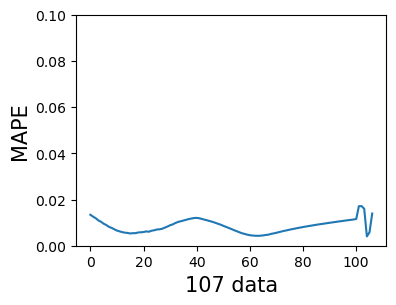

In [6]:
MAPE_data_mean=tf.reduce_mean(tf.abs(tf.exp(X_test-X_test_reconstructed)-1),axis=0)
plt.figure(figsize=(4,3))
plt.plot(MAPE_data_mean)
plt.ylim(0,0.1)
plt.ylabel('MAPE',fontsize=15)
plt.xlabel('107 data',fontsize=15)

print('cs2 MAPE: ', tf.reduce_mean(MAPE_data_mean[:101]))
print('cc boundary MAPE: ', tf.reduce_mean(MAPE_data_mean[101:104]))
print('max boundary MAPE: ', tf.reduce_mean(MAPE_data_mean[104:]))

In [21]:
#mu_k_all, mu_u_all, log_var_u_all, z_all = encoder(scaler_X.transform(np.concatenate((X_train,X_val, X_test))), training=False)
mu_k_all, mu_u_all, log_var_u_all, z_all = encoder(scaler_X.transform(X_test), training=False)
y_obs_all = scaler_y.inverse_transform(mu_k_all)
MmaxR14z_all=np.concatenate((y_obs_all, np.array(z_all)[:,[2]]), axis=1)
MmaxR14z_all=np.concatenate((y_obs_all, mu_u_all), axis=1)
n_trans=np.exp(X_test[:,-6])

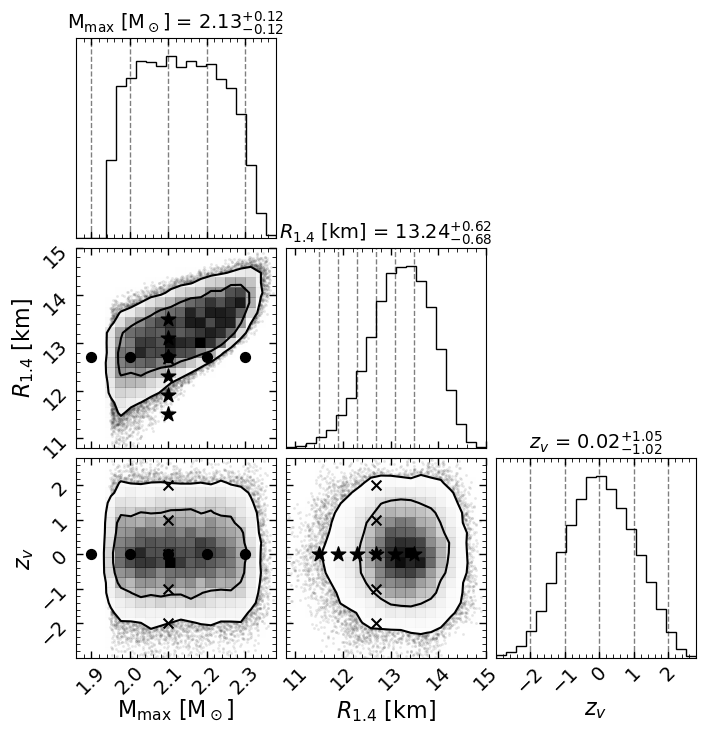

In [16]:

import corner
import matplotlib.pyplot as plt

ranges = [
    (1.86, 2.38),   # Mmax
    (10.8, 15), # R1.4
    (-3, 2.8)    # z_v
]

fig = corner.corner(
    MmaxR14z_all,
    labels=[r"M$_{{\rm max}}$ [M$_\odot$]", r"$R_{1.4}$ [km]", r"$z_v$"],
    bins=20,
    range=ranges,
    show_titles=True,
    title_fmt=".2f",
    plot_datapoints=True,
    fill_contours=False,
    levels=[0.68, 0.95],
    label_kwargs={"fontsize":16},
    title_kwargs={"fontsize":14},
    max_n_ticks=6,
)


axes = np.array(fig.axes).reshape((3,3))

# mark Mmax sweep at fixed R14
for M,R in zip(Mmax_plot, R14_fixed):
    axes[1,0].scatter(M, R, color='k', s=50, zorder=10)
    axes[2,0].scatter(M, 0, color='k', s=50, zorder=10)

# mark R14 sweep at fixed Mmax
for R in R14_plot:
    axes[1,0].scatter(MmaxR14_plot[0], R, marker='*', color='k', s=120, zorder=10)
    axes[2,1].scatter(R, 0              , marker='*', color='k', s=120, zorder=10)

for z in np.linspace(-2,2,5):
    axes[2,0].scatter(MmaxR14_plot[0], z, marker='x', color='k', s=50, zorder=10)
    axes[2,1].scatter(MmaxR14_plot[1], z, marker='x', color='k', s=50, zorder=10)


# central point
axes[1,0].scatter(
    MmaxR14_plot[0], MmaxR14_plot[1],
    marker='*', color='k', s=120, zorder=20
)


# optional: vertical lines on diagonal
for M in Mmax_plot:
    axes[0,0].axvline(M, color='k',ls='--',lw=1, alpha=0.5)

for R in R14_plot:
    axes[1,1].axvline(R, color='k',ls='--',lw=1, alpha=0.5)

for z in np.linspace(-2,2,5):
    axes[2,2].axvline(z, color='k',ls='--',lw=1, alpha=0.5)

# bottom row: x labels
for j in range(3):
    axes[2, j].xaxis.set_label_coords(0.5, -0.2)

# left column: y labels
for i in range(1, 3):
    axes[i, 0].yaxis.set_label_coords(-0.2, 0.5)

R_ticks = [11, 12, 13, 14, 15]

# R1.4 appears as x-axis in these panels
axes[1,1].set_xticks(R_ticks)
axes[2,1].set_xticks(R_ticks)

# R1.4 appears as y-axis here
axes[1,0].set_yticks(R_ticks)
    
plt.savefig('./figures/MmaxR14zv_latent_skyrme.pdf',bbox_inches = 'tight',format='pdf')#, dpi=dpi)
plt.show()

In [23]:
np.corrcoef(MmaxR14z_all[:,0],MmaxR14z_all[:,1])

array([[1.        , 0.62586733],
       [0.62586733, 1.        ]])

In [9]:
# check if mean in latent space is correctly reproduced
latent_mean=np.array([np.array(z_test).mean(axis=0)])
print("latent_mean=",latent_mean)
print(scaler_y.inverse_transform(latent_mean[:,:2]))

reconstructed_test_scaled = decoder(latent_mean, training=False).numpy()
#reconstructed_test_original = np.exp(scaler_X.inverse_transform(reconstructed_test_scaled))
reconstructed_test_original = np.exp(reconstructed_test_scaled)

print('data boundary=',reconstructed_test_original[0,101:])
    
eos_data=reconstructed_test_original[0]
print(eos_data)

def f(lnp,eps_lnn,cs2):
    eps,lnn=eps_lnn
    p=np.exp(lnp)
    deps_dlnp=p/cs2(lnp)
    dlnn_dlnp=deps_dlnp/(eps+p)
    return np.array([deps_dlnp,dlnn_dlnp])

from scipy import interpolate
from tov_f import lsoda_ode_array
from eos_class import EOS_SLY4,EOS_interpolation
eos_sly4=EOS_SLY4()

lnp_array=np.linspace(np.log(eos_data[103]),np.log(eos_data[106]),101)
cs2_int=interpolate.UnivariateSpline(lnp_array,eos_data[:101], k=2,s=0)
sol=lsoda_ode_array(f,1e-10,[eos_data[102],np.log(eos_data[101])],np.log(eos_data[103]),lnp_array,cs2_int,method='lsoda')
eos_array=np.array([np.exp(sol[:,1]),sol[:,0],np.exp(lnp_array)])

eos_array_complete=np.concatenate((eos_sly4.eos_array[:,np.min(eos_sly4.eos_array<0.9*eos_array[:,[0]],axis=0)],eos_array),axis=1)
eos=EOS_interpolation(0.16,eos_array_complete)

#print(MassRadius(100,1e-8, Preset_rtol,'MR',eos))
#plt.plot(eos_array_complete[0],eos_array_complete[2])

from FindMaxmass import Maxmass
from MassRadius_hadronic import MassRadius
from Find_OfMass import Properity_ofmass
Preset_Pressure_final, Preset_rtol=1e-8,1e-6
#MassRadius(eos_data[-1],Preset_Pressure_final, Preset_rtol,'MR',eos)
print("Maxmass=",Maxmass(Preset_Pressure_final, Preset_rtol, eos)[1:3]) #compare with eos_data[-1],latent_mean[0,0])
print("R_1.4=",Properity_ofmass(1.4,10,eos_data[-1],MassRadius,Preset_Pressure_final,Preset_rtol,1,eos)[2]/1e3) # compare with,latent_mean[0,1])

latent_mean= [[-0.00099077 -0.00080514  0.01653125]]
[[ 2.1317723 13.211669 ]]
data boundary= [7.0538811e-02 6.6664383e+01 3.6890304e-01 1.0940046e+00 1.4026239e+03
 6.7085370e+02]
[1.6913418e-02 1.7663164e-02 1.8546173e-02 1.9459456e-02 2.0421078e-02
 2.1418206e-02 2.2438943e-02 2.3529451e-02 2.4670854e-02 2.5839649e-02
 2.7086869e-02 2.8400049e-02 2.9719735e-02 3.1162674e-02 3.2650169e-02
 3.4188647e-02 3.5785779e-02 3.7528154e-02 3.9276525e-02 4.1097619e-02
 4.2979222e-02 4.4861533e-02 4.6924088e-02 4.8875414e-02 5.0968405e-02
 5.3083569e-02 5.5229496e-02 5.7520084e-02 5.9821151e-02 6.2287025e-02
 6.4813577e-02 6.7519382e-02 7.0293158e-02 7.3333822e-02 7.6587811e-02
 8.0073021e-02 8.3722942e-02 8.7481685e-02 9.1360487e-02 9.5568791e-02
 9.9803634e-02 1.0435743e-01 1.0903934e-01 1.1383075e-01 1.1904205e-01
 1.2433842e-01 1.2992612e-01 1.3564716e-01 1.4183204e-01 1.4808378e-01
 1.5442875e-01 1.6136260e-01 1.6858995e-01 1.7596570e-01 1.8343331e-01
 1.9135711e-01 1.9948336e-01 2.0802291

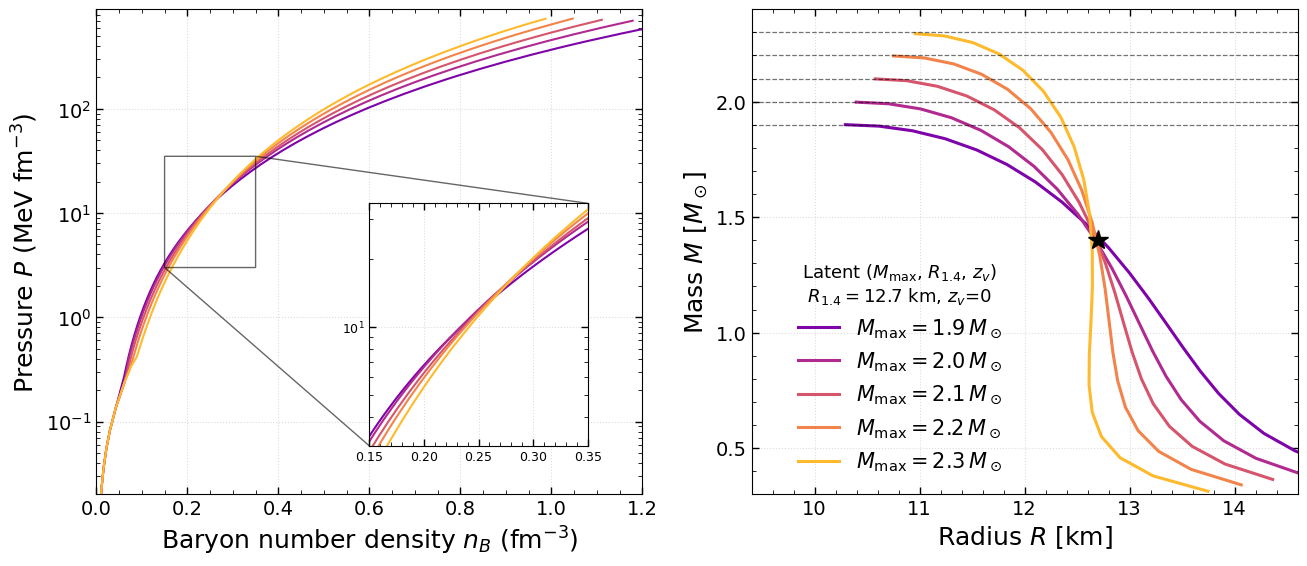

In [10]:
from matplotlib_rc import *
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

mpl.rcParams.update({
    "figure.figsize": (15.5, 6.3),
    "axes.labelsize": 18,
    "axes.titlesize": 22,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
    #"font.family": "serif",
    #"mathtext.fontset": "dejavuserif",
})

fig, (ax_eos, ax_mr) = plt.subplots(1, 2, sharey=False)
plt.subplots_adjust(wspace=0.2)

colors = mpl.cm.plasma(np.linspace(0.25, 0.85, len(Mmax_plot)))
labels = [fr"$M_{{\max}}={m:.1f}\,M_\odot$" for m in Mmax_plot]

idx_center = len(Mmax_plot) // 2
latent_handles = []
latent_labels  = []

n_trans=[]
for idx, (Mmax_i, R14_i, col, lab) in enumerate(zip(Mmax_plot, R14_fixed, colors, labels)):
    latent_test = np.concatenate(
        (scaler_y.transform([[Mmax_i, R14_i]]), [[0]*latent_dim_variational]),
        axis=1
    )
    reconstructed_test_scaled = decoder(latent_test, training=False).numpy()
    reconstructed_test_original = np.exp(reconstructed_test_scaled)
    eos_data = reconstructed_test_original[0]

    lnp_array = np.linspace(np.log(eos_data[103]), np.log(eos_data[106]), 101)
    cs2_int   = interpolate.UnivariateSpline(lnp_array, eos_data[:101], k=2, s=0)
    sol = lsoda_ode_array(
        f, 1e-10,
        [eos_data[102], np.log(eos_data[101])],
        np.log(eos_data[103]),
        lnp_array,
        cs2_int,
        method="lsoda"
    )
    eos_array = np.array([np.exp(sol[:, 1]), sol[:, 0], np.exp(lnp_array)])
    eos_array_complete = np.concatenate(
        (
            eos_sly4.eos_array[
                :, np.min(eos_sly4.eos_array < 0.9 * eos_array[:, [0]], axis=0)
            ],
            eos_array
        ),
        axis=1
    )
    eos = EOS_interpolation(0.16, eos_array_complete)

    curve_color = col
    nB = eos_array_complete[0]
    P  = eos_array_complete[2]

    ax_eos.plot(nB, P, lw=1.5, color=curve_color)

    MR_data = []
    for pc in np.exp(np.linspace(np.log(5), np.log(eos_data[-1]), 20)):
        MR_data.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos))
    MR_data = np.array(MR_data).T

    line_mr, = ax_mr.plot(MR_data[1]/1000.0, MR_data[0], lw=2.2, color=curve_color)
    latent_handles.append(line_mr)
    latent_labels.append(lab)

# ax_eos.plot(
#     eos_sly4.eos_array[0], eos_sly4.eos_array[2],
#     lw=2.4, ls="--", color="0.25"
# )
ax_eos.set_yscale('log')
ax_eos.set_ylim(2e-2, 900)
ax_eos.set_xlim(0, 1.2)

ax_inset = ax_eos.inset_axes([.5, 0.1, 0.4, 0.5])  # [x, y, width, height] in axes fraction

for idx, (Mmax_i, R14_i, col, lab) in enumerate(zip(Mmax_plot, R14_fixed, colors, labels)):
    latent_test = np.concatenate(
        (scaler_y.transform([[Mmax_i, R14_i]]), [[0]*latent_dim_variational]),
        axis=1
    )
    reconstructed_test_scaled = decoder(latent_test, training=False).numpy()
    reconstructed_test_original = np.exp(reconstructed_test_scaled)
    eos_data = reconstructed_test_original[0]
    n_trans.append(eos_data[-6])

    lnp_array = np.linspace(np.log(eos_data[103]), np.log(eos_data[106]), 101)
    cs2_int   = interpolate.UnivariateSpline(lnp_array, eos_data[:101], k=2, s=0)
    sol = lsoda_ode_array(
        f, 1e-10,
        [eos_data[102], np.log(eos_data[101])],
        np.log(eos_data[103]),
        lnp_array,
        cs2_int,
        method="lsoda"
    )
    eos_array = np.array([np.exp(sol[:, 1]), sol[:, 0], np.exp(lnp_array)])
    eos_array_complete = np.concatenate(
        (
            eos_sly4.eos_array[
                :, np.min(eos_sly4.eos_array < 0.9 * eos_array[:, [0]], axis=0)
            ],
            eos_array
        ),
        axis=1
    )
    nB = eos_array_complete[0]
    P  = eos_array_complete[2]
    ax_inset.plot(nB, P, lw=1.5, color=col)

#ax_inset.plot(eos_sly4.eos_array[0], eos_sly4.eos_array[2], lw=1.8, ls="--", color="0.25")
ax_inset.set_xlim(0.15, 0.35)
ax_inset.set_ylim(3, 35)
ax_inset.set_yscale('log')
ax_inset.tick_params(labelsize=9)
ax_inset.grid(True, ls=":", alpha=0.45)
# ax_inset.set_xlabel(r"$n_B$", fontsize=10)
# ax_inset.set_ylabel(r"$P$", fontsize=10)

ax_eos.indicate_inset_zoom(ax_inset, edgecolor="black", alpha=0.6)

for y_i in Mmax_plot:
    ax_mr.axhline(y=y_i, ls="--", lw=0.9, color="k", alpha=0.55)

ax_mr.plot(R14_fixed[0], 1.4, marker="*", ms=15, color="k", zorder=5)
ax_mr.set_xticks([10,11,12,13,14])
ax_mr.set_yticks([0.5,1,1.5,2])
ax_eos.set_xlabel("Baryon number density $n_B$ (fm$^{-3}$)")
ax_eos.set_ylabel("Pressure $P$ (MeV fm$^{-3}$)")
ax_mr.set_xlabel("Radius $R$ [km]")
ax_mr.set_ylabel("Mass $M$ [$M_\odot$]")
ax_eos.grid(True, ls=":", alpha=0.45)
ax_mr.grid(True, ls=":", alpha=0.45)
ax_mr.set_xlim(9.4, 14.6)
ax_mr.set_ylim(0.3, 2.4)

handles_sly4 = []
handles = handles_sly4 + latent_handles
labels  = [h.get_label() for h in handles_sly4] + latent_labels
fig.legend(
    handles, labels,
    title="Latent ($M_{{\\rm max}}$, $R_{1.4}$, $z_v$)\n $R_{1.4}=%.1f$ km, $z_v$=0"%MmaxR14_plot[1],
    title_fontsize=13,
    frameon=False,
    framealpha=0.9,
    borderpad=0.8,
    loc="lower left",
    bbox_to_anchor=(0.56, 0.1))
plt.savefig('./figures/fix_R14_skyrme.pdf',bbox_inches = 'tight',format='pdf')#, dpi=dpi)
plt.show()


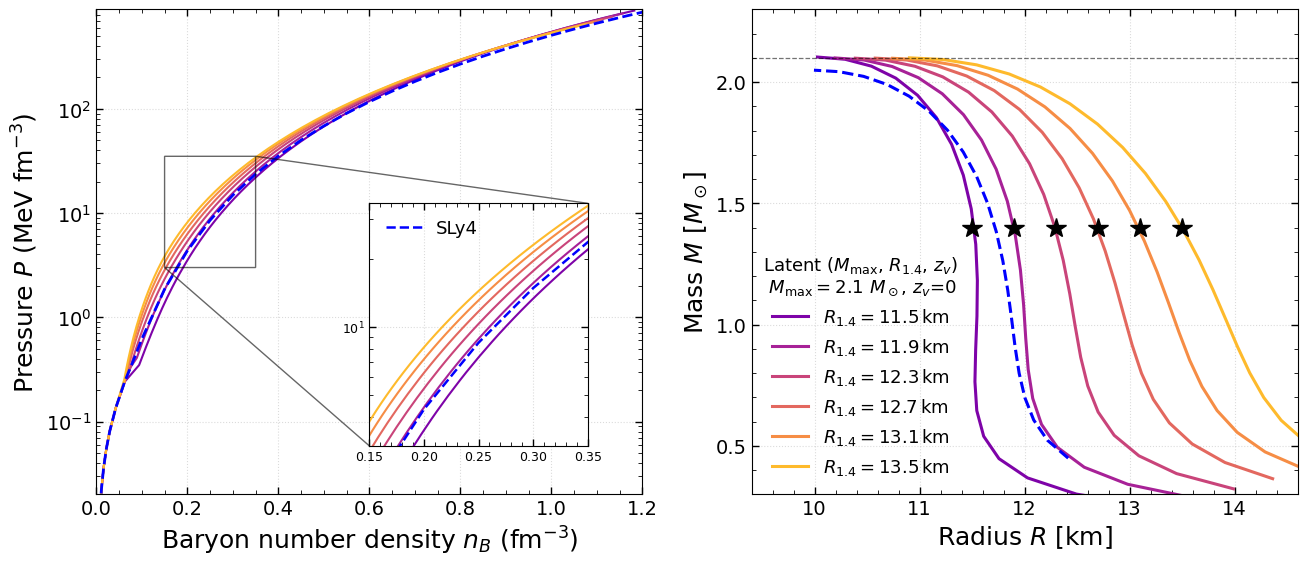

In [11]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate
from eos_class import EOS_SLY4, EOS_interpolation

mpl.rcParams.update({
    "figure.figsize": (15.5, 6.3),
    "axes.labelsize": 18,
    "axes.titlesize": 22,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    #"font.family": "serif",
    #"mathtext.fontset": "dejavuserif",
})

eos_sly4 = EOS_SLY4()

R0 = float(MmaxR14_plot[1])     # baseline R_1.4

colors = mpl.cm.plasma(np.linspace(0.25, 0.85, len(R14_plot)))
labels = [fr"$R_{{1.4}}={r:.1f}\,\mathrm{{km}}$" for r in R14_plot]
idx_center = int(np.argmin(np.abs(R14_plot - R0)))

fig, (ax_eos, ax_mr) = plt.subplots(1, 2, sharey=False)
plt.subplots_adjust(wspace=0.2)

latent_handles, latent_labels = [], []

ax_inset = ax_eos.inset_axes([.5, 0.1, 0.4, 0.5])  # [x, y, width, height] in axes fraction

for j, (R14_i, col, lab) in enumerate(zip(R14_plot, colors, labels)):

    latent_test = np.concatenate(
        (scaler_y.transform([[MmaxR14_plot[0], R14_i]]), [[0]*latent_dim_variational]),
        axis=1
    )

    reconstructed_test_scaled = decoder(latent_test, training=False).numpy()
    reconstructed_test_original = np.exp(reconstructed_test_scaled)
    eos_data = reconstructed_test_original[0]


    lnp_array = np.linspace(np.log(eos_data[103]), np.log(eos_data[106]), 101)
    cs2_int   = interpolate.UnivariateSpline(lnp_array, eos_data[:101], k=2, s=0)

    sol = lsoda_ode_array(
        f, 1e-10,
        [eos_data[102], np.log(eos_data[101])],
        np.log(eos_data[103]),
        lnp_array,
        cs2_int,
        method="lsoda"
    )

    eos_array = np.array([np.exp(sol[:, 1]), sol[:, 0], np.exp(lnp_array)])

    eos_array_complete = np.concatenate(
        (
            eos_sly4.eos_array[
                :, np.min(eos_sly4.eos_array < 0.9 * eos_array[:, [0]], axis=0)
            ],
            eos_array
        ),
        axis=1
    )
    eos = EOS_interpolation(0.16, eos_array_complete)

    #curve_color = "k" if j == idx_center else col
    curve_color = col

    nB = eos_array_complete[0]
    P  = eos_array_complete[2]
    ax_eos.plot(nB, P, lw=1.5, color=curve_color)

    MR_data = []
    for pc in np.exp(np.linspace(np.log(5), np.log(eos_data[-1]), 20)):
        MR_data.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos))
    MR_data = np.array(MR_data).T

    line_mr, = ax_mr.plot(MR_data[1]/1000.0, MR_data[0], lw=2.2, color=curve_color)

    latent_handles.append(line_mr)
    latent_labels.append(lab)

    ax_inset.plot(nB, P, lw=1.5, color=col)

ax_inset.plot(eos_sly4.eos_array[0], eos_sly4.eos_array[2], lw=1.8, ls="--", color="b",label='SLy4')
ax_inset.set_xlim(0.15, 0.35)
ax_inset.set_ylim(3, 35)
ax_inset.set_yscale('log')
ax_inset.tick_params(labelsize=9)
ax_inset.grid(True, ls=":", alpha=0.45)
# ax_inset.set_xlabel(r"$n_B$", fontsize=10)
# ax_inset.set_ylabel(r"$P$", fontsize=10)

ax_inset.legend(frameon=False,fontsize=13,
    loc="upper left",
    bbox_to_anchor=(0, 1))

ax_eos.indicate_inset_zoom(ax_inset, edgecolor="black", alpha=0.6)

ax_eos.plot(
    eos_sly4.eos_array[0], eos_sly4.eos_array[2],
    lw=2, ls="--", color="b", label=r"SLy4"
)
ax_eos.set_yscale('log')
ax_eos.set_ylim(2e-2, 900)
#ax_eos.set_ylim(100, 900)
ax_eos.set_xlim(0, 1.2)

eos_sly4_interp = EOS_interpolation(0.16, eos_sly4.eos_array)
pc_vals_sly4 = np.exp(np.linspace(np.log(10), np.log(855), 20))

MR_sly4 = []
for pc in pc_vals_sly4:
    MR_sly4.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos_sly4_interp))
MR_sly4 = np.array(MR_sly4).T

ax_mr.plot(
    MR_sly4[1]/1000.0, MR_sly4[0],
    lw=2.2, ls="--", color="b")

[ax_mr.plot(R14_i, 1.4, marker="*", ms=15, color='k') for R14_i in R14_plot]
ax_mr.axhline(y=MmaxR14_plot[0], ls="--", lw=0.9, color="k", alpha=0.55)

ax_mr.set_xticks([10,11,12,13,14])
ax_mr.set_yticks([0.5,1,1.5,2])
ax_eos.set_xlabel(r"Baryon number density $n_B$ (fm$^{-3}$)")
ax_eos.set_ylabel(r"Pressure $P$ (MeV fm$^{-3}$)")
ax_mr.set_xlabel(r"Radius $R$ [km]")
ax_mr.set_ylabel(r"Mass $M$ [$M_\odot$]")
ax_eos.grid(True, ls=":", alpha=0.45)
ax_mr.grid(True, ls=":", alpha=0.45)
ax_mr.set_xlim(9.4, 14.6)
ax_mr.set_ylim(0.3, 2.3)

# handles_sly4 = [
#     mpl.lines.Line2D([], [], lw=2.4, ls="--", color="0.25", label=r"SLy4"),
#     mpl.lines.Line2D([], [], lw=2.2, color="k", label=r"center"),
# ]
handles_sly4 =[]

handles = handles_sly4 + latent_handles
labels  = [h.get_label() for h in handles_sly4] + latent_labels

fig.legend(
    handles, labels,
    title="Latent ($M_{{\\rm max}}$, $R_{1.4}$, $z_v$)\n $M_{{\\rm max}}=%.1f~M_\odot$, $z_v$=0"%MmaxR14_plot[0],
    title_fontsize=13,
    frameon=False,
    framealpha=0.9,
    borderpad=0.8,
    loc="lower left",
    bbox_to_anchor=(0.54, 0.1))
plt.savefig('./figures/fix_Mmax_skyrme.pdf',bbox_inches = 'tight',format='pdf')#, dpi=dpi)
plt.show()


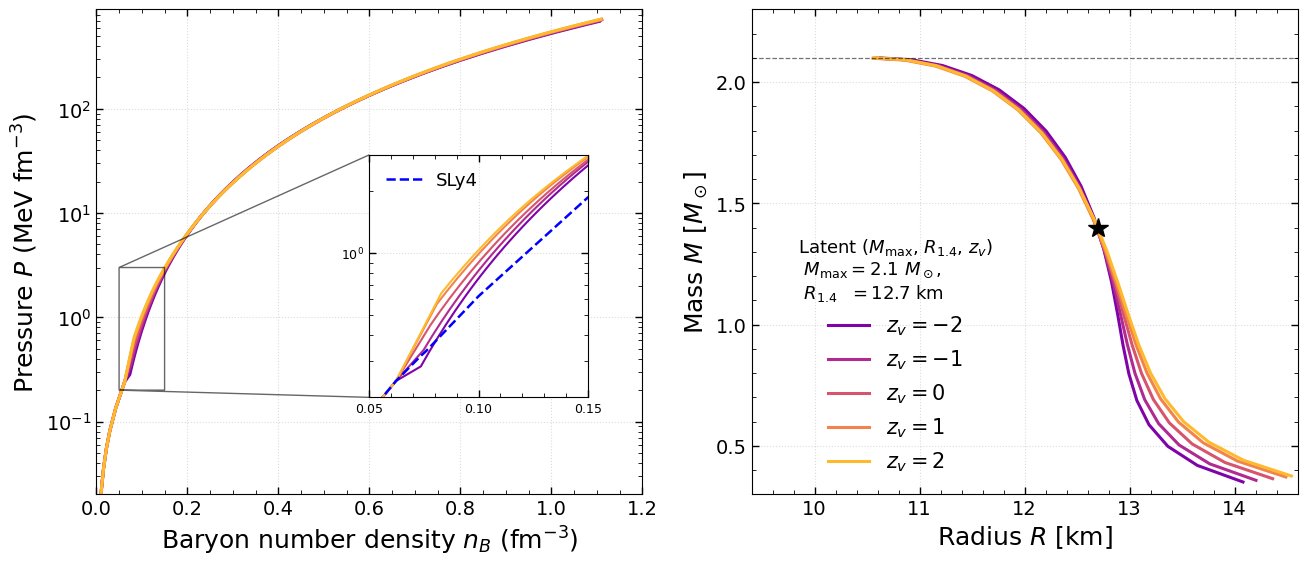

In [13]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import interpolate
from eos_class import EOS_SLY4, EOS_interpolation

mpl.rcParams.update({
    "figure.figsize": (15.5, 6.3),
    "axes.labelsize": 18,
    "axes.titlesize": 22,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,
    #"font.family": "serif",
    #"mathtext.fontset": "dejavuserif",
})

eos_sly4 = EOS_SLY4()

factors = np.array([-2, -1, 0, 1, 2], dtype=float)
factor_colors = mpl.cm.plasma(np.linspace(0.25, 0.85, len(factors)))
factor_labels = [fr"$z_v={fac:g}$" for k, fac in zip(range(len(factors)), factors)]

for i in range(latent_dim_variational):

    fig, (ax_eos, ax_mr) = plt.subplots(1, 2, sharey=False)
    plt.subplots_adjust(wspace=0.20)

    latent_handles = []
    latent_labels  = []

    ax_inset = ax_eos.inset_axes([.5, 0.2, 0.4, 0.5])  # [x, y, width, height] in axes fraction

    for j, (factor, col, lab) in enumerate(zip(factors, factor_colors, factor_labels)):

        latent_test = np.concatenate(
            (scaler_y.transform([MmaxR14_plot]), [[0]*latent_dim_variational]),
            axis=1
        )
        latent_test[0, i+2] = factor

        reconstructed_test_scaled = decoder(latent_test, training=False).numpy()
        reconstructed_test_original = np.exp(reconstructed_test_scaled)
        eos_data = reconstructed_test_original[0]

        if(j == 0):
            eos_data_center = eos_data

        lnp_array = np.linspace(np.log(eos_data[103]), np.log(eos_data[106]), 101)
        cs2_int   = interpolate.UnivariateSpline(lnp_array, eos_data[:101], k=2, s=0)

        sol = lsoda_ode_array(
            f, 1e-10,
            [eos_data[102], np.log(eos_data[101])],
            np.log(eos_data[103]),
            lnp_array,
            cs2_int,
            method="lsoda"
        )

        eos_array = np.array([np.exp(sol[:, 1]), sol[:, 0], np.exp(lnp_array)])

        eos_array_complete = np.concatenate(
            (
                eos_sly4.eos_array[
                    :, np.min(eos_sly4.eos_array < 0.87 * eos_array[:, [0]], axis=0)
                ],
                eos_array
            ),
            axis=1
        )
        eos = EOS_interpolation(0.16, eos_array_complete)

        #curve_color = "k" if j == idx_center else col
        curve_color=col

        nB = eos_array_complete[0]
        P  = eos_array_complete[2]
        ax_eos.plot(nB, P, lw=2.2, color=curve_color)

        MR_data = []
        for pc in np.exp(np.linspace(np.log(5), np.log(eos_data[-1]), 20)):
            MR_data.append(MassRadius(pc, Preset_Pressure_final, Preset_rtol, "MR", eos))
        MR_data = np.array(MR_data).T

        line_mr, = ax_mr.plot(MR_data[1]/1000.0, MR_data[0], lw=2.2, color=curve_color)

        latent_handles.append(line_mr)
        latent_labels.append(lab)
    
        ax_inset.plot(nB, P, lw=1.5, color=col)

    ax_eos.set_yscale('log')
    ax_eos.set_ylim(2e-2, 900)
    ax_eos.set_xlim(0, 1.2)

    ax_inset.plot(eos_sly4.eos_array[0], eos_sly4.eos_array[2], lw=1.8, ls="--", color="b",label='SLy4')
    ax_inset.set_xlim(0.05, 0.15)
    ax_inset.set_ylim(2e-1, 3)
    ax_inset.set_xticks([0.05, 0.1, 0.15])
    ax_inset.set_yscale('log')
    ax_inset.tick_params(labelsize=9)
    ax_inset.grid(True, ls=":", alpha=0.45)
    # ax_inset.set_xlabel(r"$n_B$", fontsize=10)
    # ax_inset.set_ylabel(r"$P$", fontsize=10)
    ax_inset.legend(frameon=False,fontsize=13,
    loc="upper left",
    bbox_to_anchor=(0, 1))
    
    ax_eos.indicate_inset_zoom(ax_inset, edgecolor="black", alpha=0.6)
    
    ax_mr.axhline(y=MmaxR14_plot[0], ls="--", lw=0.9, color="k", alpha=0.55)
    ax_mr.plot(R14_fixed[0], 1.4, marker="*", ms=15, color="k", zorder=5)
    ax_mr.set_yticks([0.5,1,1.5,2,2.5])
    ax_eos.set_xlabel(r"Baryon number density $n_B$ (fm$^{-3}$)")
    ax_eos.set_ylabel(r"Pressure $P$ (MeV fm$^{-3}$)")
    ax_mr.set_xlabel(r"Radius $R$ [km]")
    ax_mr.set_ylabel(r"Mass $M$ [$M_\odot$]")
    ax_eos.grid(True, ls=":", alpha=0.45)
    ax_mr.grid(True, ls=":", alpha=0.45)
    ax_mr.set_xlim(9.4, 14.6)
    ax_mr.set_ylim(0.3, 2.3)
    
    handles_sly4 = []
    handles = handles_sly4 + latent_handles
    labels  = [h.get_label() for h in handles_sly4] + latent_labels
    fig.legend(
        handles, labels,
        title="Latent ($M_{{\\rm max}}$, $R_{1.4}$, $z_v$)\n $M_{{\\rm max}}=%.1f~M_\odot$,\n $R_{1.4}~~=%.1f$ km"%tuple(MmaxR14_plot),
        title_fontsize=13,
        frameon=False,
        framealpha=0.9,
        borderpad=0.8,
        loc="lower left",
        bbox_to_anchor=(0.56, 0.1))
    plt.savefig('./figures/fix_R14Mmax_skyrme.pdf',bbox_inches = 'tight',format='pdf')#, dpi=dpi)
    plt.show()